In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import sys
import tensorflow as tf

import pandas as pd

# Load data (handling potential byte order mark)
serial_samples_annotation = pd.read_csv('/users/audreysu/MyCovidProject/Transcriptomics/serial_samples_annotation.csv')
serial_norm_gene_exp_df = pd.read_csv('/users/audreysu/MyCovidProject/Transcriptomics/serial_norm_gene_exp_df.csv')

# Transpose and set column names from 'Unnamed: 0'
serial_norm_gene_exp_df_transposed = serial_norm_gene_exp_df.set_index('Unnamed: 0').T #Set gene names as index *before* transposing

# Set 'X' column as index in serial_samples_annotation
serial_samples_annotation = serial_samples_annotation.set_index('X')

# Merge the dataframes based on 'X' (original identifier) from annotation and index from gene data
merged_df = pd.merge(serial_samples_annotation, serial_norm_gene_exp_df_transposed, left_on='X', right_index=True, how='inner')
merged_df.head()

,Subject,Day,Delirium,Diagnosis,Steroids,Late_del,DPM1,SCYL3,C1orf112,FGR,...,BISPR,TRBV7-2,LOC729998,GTF2IP12,TRBV6-3,C13orf46,CNTNAP3C,MIR1244-2,EXOC3L2,LINC02009
X,,,,,,,,,,,,,,,,,,,,,
MVIR1.HS101.D0PBMC1.RSQ1,101,0,1,1,0,0,9.383461,8.366948,7.891559,12.660471,...,8.484131,6.133350,9.163414,7.026587,5.091633,10.232327,4.495889,7.485804,5.181471,4.109131
MVIR1.HS101.D21PBMC1.RSQ1,101,21,2,1,0,0,10.310383,7.956377,6.741496,14.552471,...,8.742996,7.094224,6.386183,5.610242,5.535193,5.367325,6.153656,7.918214,5.165732,4.904291
MVIR1.HS101.D4PBMC1.RSQ1,101,4,0,1,0,0,10.375083,7.873112,7.468121,13.870511,...,9.311721,7.382531,6.777208,5.577385,5.673409,5.415525,4.109131,8.144562,5.291724,4.109131
MVIR1.HS101.D7PBMC1.RSQ1,101,7,0,1,0,0,10.371731,7.121040,7.248001,13.819690,...,9.145124,7.293930,7.257307,5.505941,5.703401,5.469294,4.450575,8.476149,5.391949,4.109131
MVIR1.HS107.D0PBMC1.RSQ1,107,7,0,1,0,1,9.310316,8.173659,7.445675,13.415327,...,7.983009,8.186661,9.086468,6.955933,6.903513,8.910014,5.652481,7.386398,7.016331,6.826619


2/2 [==============================] - 0s 10ms/step

LSTM Model:
  ROC AUC Score: 0.86
  Precision: 0.78
  Recall: 0.75
              precision    recall  f1-score   support

           0       0.71      0.74      0.72        23
           1       0.78      0.75      0.76        28

    accuracy                           0.75        51
   macro avg       0.74      0.74      0.74        51
weighted avg       0.75      0.75      0.75        51



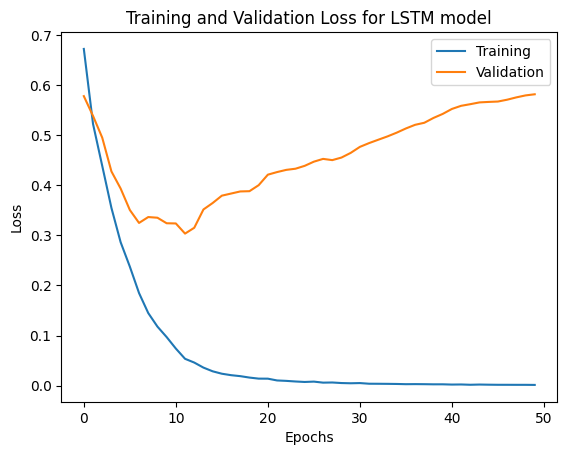

2/2 [==============================] - 0s 6ms/step

GRU Model:
  ROC AUC Score: 0.89
  Precision: 0.78
  Recall: 0.75
              precision    recall  f1-score   support

           0       0.71      0.74      0.72        23
           1       0.78      0.75      0.76        28

    accuracy                           0.75        51
   macro avg       0.74      0.74      0.74        51
weighted avg       0.75      0.75      0.75        51



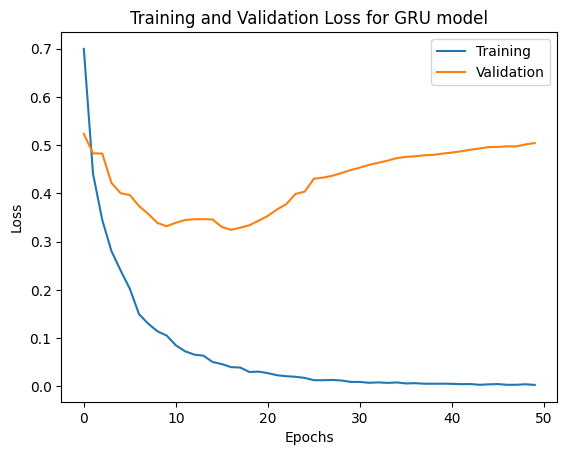

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt

# Prepare data for RNN (LSTM or GRU)
def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys).astype(int)  # Ensure y is integer

X = merged_df.drop(['Subject', 'Day', 'Delirium','Diagnosis', 'Steroids','Late_del'], axis=1)
y = merged_df['Diagnosis']

#Scale data as before
numeric_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

TIME_STEPS = 3
X, y = create_sequences(X, y, TIME_STEPS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)

# Define models (LSTM and GRU) using Functional API
def create_lstm_model(input_shape):
    input_layer = keras.Input(shape=input_shape)
    lstm1 = layers.LSTM(64, return_sequences=True)(input_layer)
    lstm2 = layers.LSTM(32)(lstm1)
    dropout = layers.Dropout(0.2)(lstm2)
    output_layer = layers.Dense(1, activation='sigmoid')(dropout)
    model = keras.Model(inputs=input_layer, outputs=output_layer)
    return model

def create_gru_model(input_shape):  # GRU Model Definition
    input_layer = keras.Input(shape=input_shape)
    gru1 = layers.GRU(64, return_sequences=True)(input_layer)  # GRU layer
    gru2 = layers.GRU(32)(gru1)  # GRU layer
    dropout = layers.Dropout(0.2)(gru2)
    output_layer = layers.Dense(1, activation='sigmoid')(dropout)
    model = keras.Model(inputs=input_layer, outputs=output_layer)
    return model

# Train and evaluate models
input_shape = (X_train.shape[1], X_train.shape[2])

models = {
    "LSTM": create_lstm_model(input_shape),
    "GRU": create_gru_model(input_shape) #Include GRU in model dictionary
}

for model_name, model in models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0) #verbose=0 to suppress training output

    y_pred_proba = model.predict(X_test).flatten()
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, (y_pred_proba > 0.5).astype(int)) #Calculate precision and recall for each model
    recall = recall_score(y_test, (y_pred_proba > 0.5).astype(int))

    print(f"\n{model_name} Model:")
    print(f"  ROC AUC Score: {roc_auc:.2f}")
    print(f"  Precision: {precision:.2f}") #Include precision and recall in output
    print(f"  Recall: {recall:.2f}")
    print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))

    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training and Validation Loss for {model_name} model')
    plt.show()

2/2 [==============================] - 0s 8ms/step
LSTM AUC: 0.857


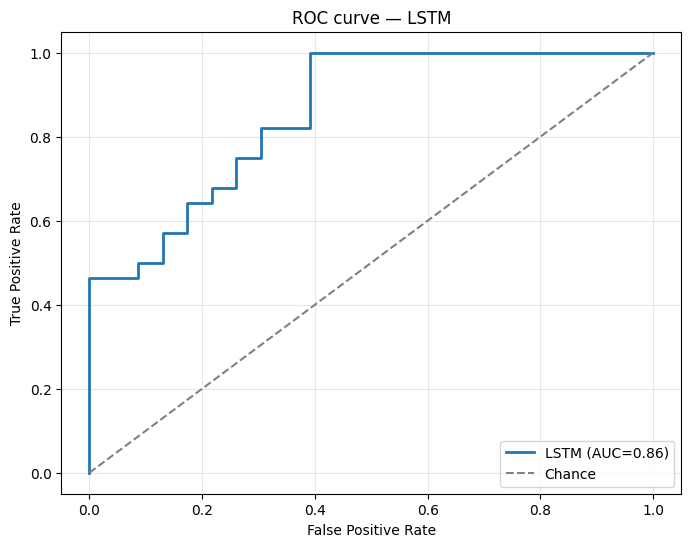

2/2 [==============================] - 0s 7ms/step
GRU AUC: 0.891


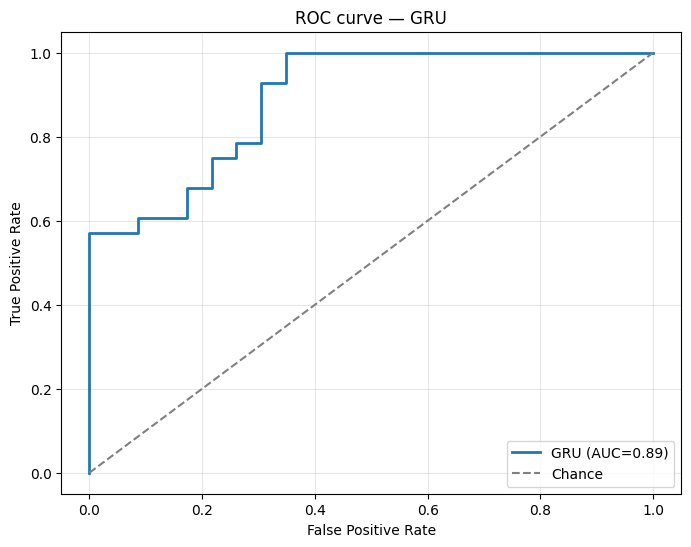

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

for name, model in models.items():
    # robust prediction
    try:
        y_pred_proba = model.predict(X_test).ravel()
    except Exception as e:
        print(f"model.predict failed for {name}: {e}; trying model(X_test, training=False)")
        preds = model(X_test, training=False)
        if hasattr(preds, 'numpy'):
            preds = preds.numpy()
        y_pred_proba = np.asarray(preds).ravel()

    # guard against single-class y_test
    uniq = np.unique(y_test)
    if len(uniq) < 2:
        print(f"Skipping ROC for {name}: y_test has only one class: {uniq}")
        continue

    try:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        print(f"{name} AUC: {auc_score:.3f}")

        # Plot ROC for this model in its own figure
        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_score:.2f})")
        plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Chance')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC curve — {name}')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"Failed to compute/plot ROC for {name}: {e}")


Computing SHAP for LSTM...
DeepExplainer failed: in user code:

    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 245, in grad_graph  *
        out = self.model(shap_rAnD)
    File "/Users/audreysu/p3/lib/python3.10/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 394, in custom_grad
        out = op_handlers[type_name](self, op, *grads)  # we cut off the shap_ prefix before the lookup
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 691, in handler
        return linearity_with_excluded_handler(input_inds, explainer, op, *grads)
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 700, in linearity_with_excluded_handler
        assert not explainer._variable_input

/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


GradientExplainer failed: in user code:

    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_gradient.py", line 250, in grad_graph  *
        x_grad = tape.gradient(out, x)

    LookupError: gradient registry has no entry for: shap_StridedSlice

Attempting KernelExplainer (may fail for some TF RNNs).


  0%|          | 0/51 [00:00<?, ?it/s]

/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=1.260e-01, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Drop

Used KernelExplainer; reshaped SHAP to: (51, 3, 13107)
aggregated SHAP shape (before align): (51, 13107)
aggregated input shape (before align): (51, 13107)
aggregated SHAP shape (aligned): (51, 13107)
features_for_plot shape (aligned): (51, 13107)


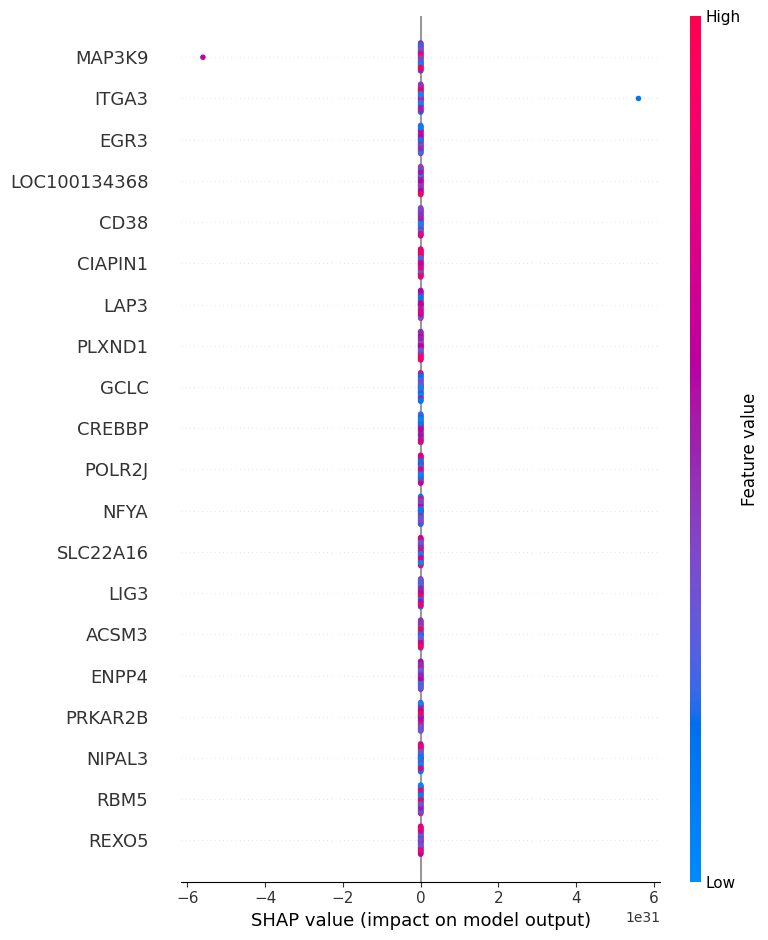

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_13951/3931683941.py:161: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_feature, features_for_plot, feature_names=feature_names, plot_type='bar', show=True)


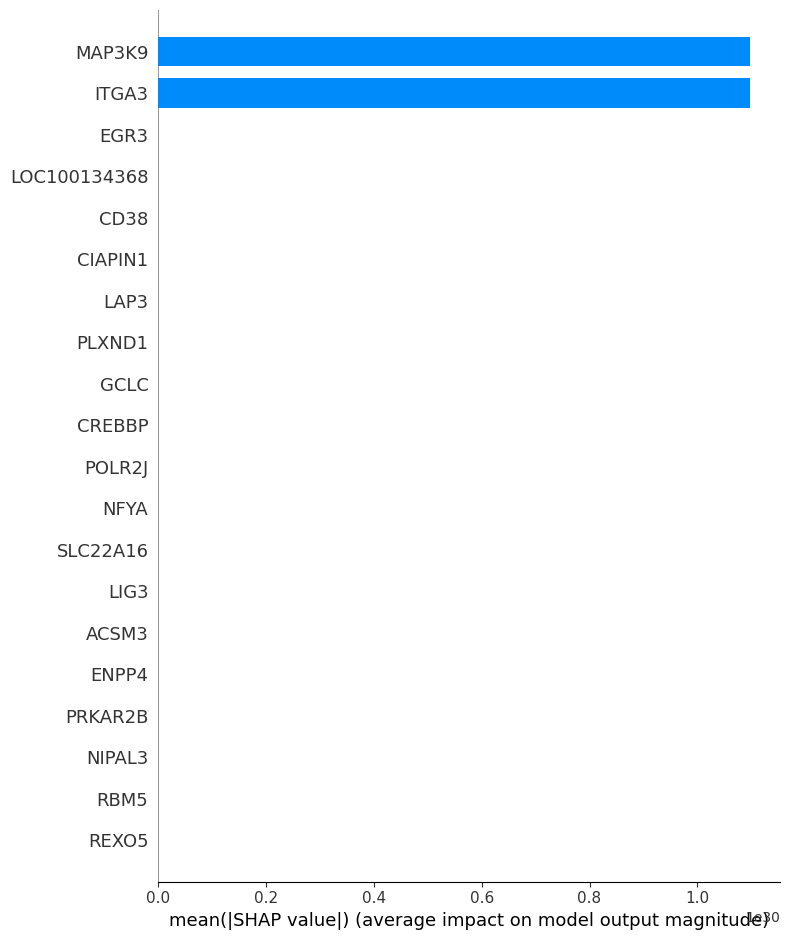

/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(



Computing SHAP for GRU...


/Users/audreysu/p3/lib/python3.10/site-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


DeepExplainer failed: in user code:

    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 245, in grad_graph  *
        out = self.model(shap_rAnD)
    File "/Users/audreysu/p3/lib/python3.10/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 394, in custom_grad
        out = op_handlers[type_name](self, op, *grads)  # we cut off the shap_ prefix before the lookup
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 691, in handler
        return linearity_with_excluded_handler(input_inds, explainer, op, *grads)
    File "/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py", line 700, in linearity_with_excluded_handler
        assert not explainer._variable_inputs(op)[i], str(i) + "th input

  0%|          | 0/51 [00:00<?, ?it/s]

/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=4.800e-01, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=2.400e-01, with an active set of 9 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Users/audreysu/p3/lib/python3.10/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the numbe

Used KernelExplainer; reshaped SHAP to: (51, 3, 13107)
aggregated SHAP shape (before align): (51, 13107)
aggregated input shape (before align): (51, 13107)
aggregated SHAP shape (aligned): (51, 13107)
features_for_plot shape (aligned): (51, 13107)


/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_13951/3931683941.py:158: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_feature, features_for_plot, feature_names=feature_names, plot_type='dot', show=True)


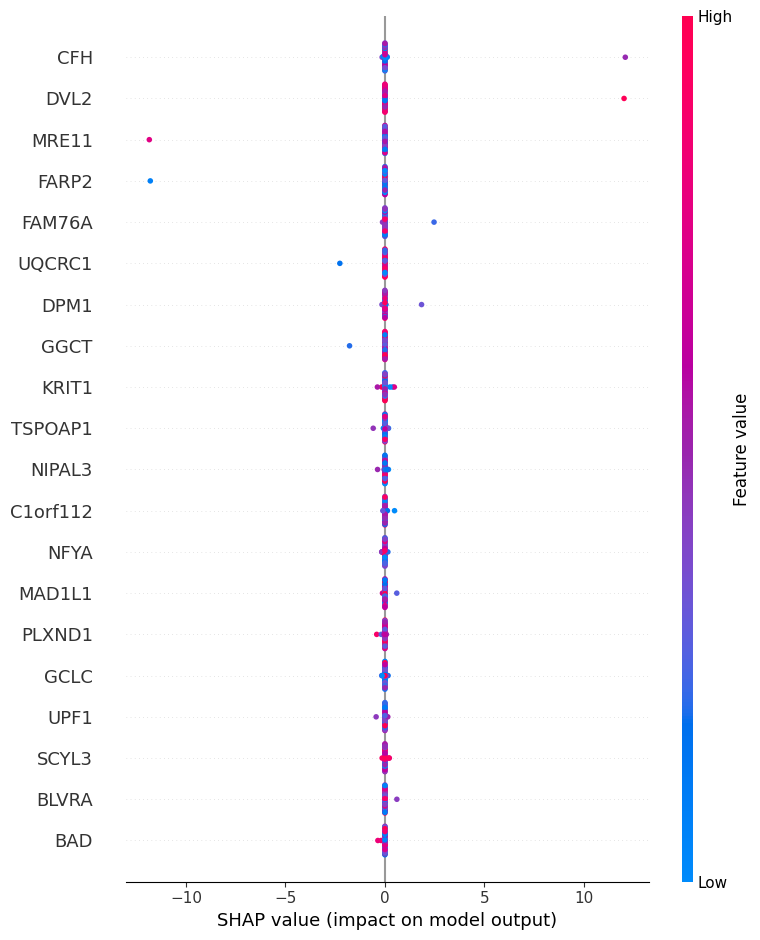

/var/folders/fz/lz55mbm51216f101cqgbdzlh0000gn/T/ipykernel_13951/3931683941.py:161: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_feature, features_for_plot, feature_names=feature_names, plot_type='bar', show=True)


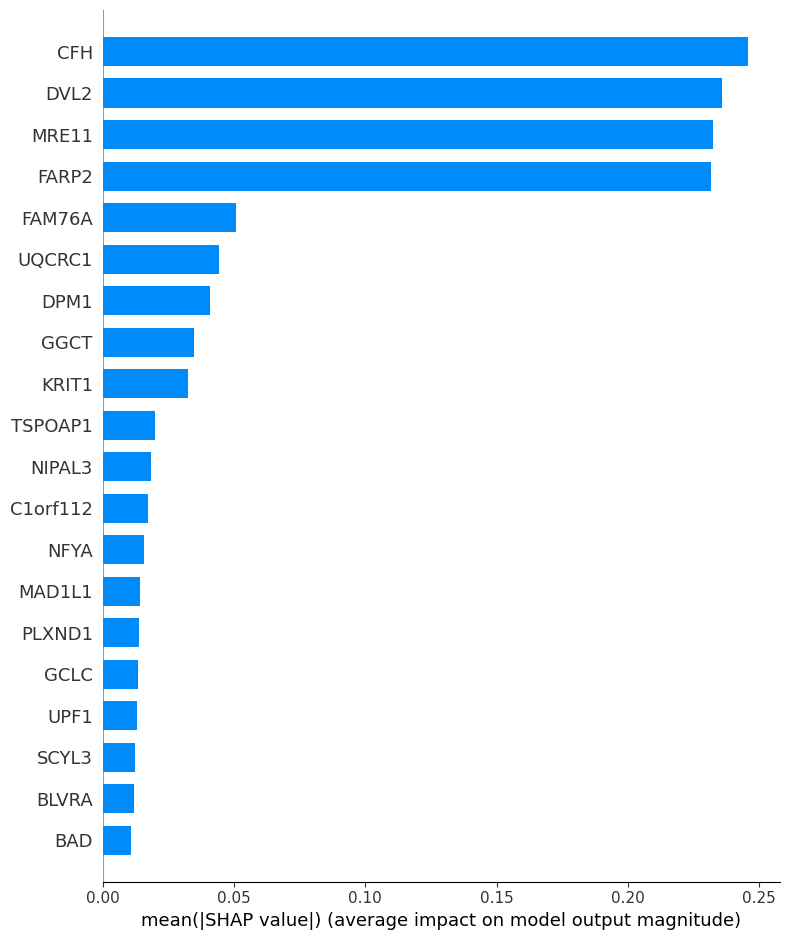

In [4]:
# SHAP plots for LSTM and GRU models
import tensorflow as tf
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Reconstruct original feature names (columns used before sequence creation)
original_features = merged_df.drop(['Subject', 'Day', 'Delirium','Diagnosis', 'Steroids','Late_del'], axis=1).columns.tolist()

# Small background and test subset to keep SHAP fast
bg_n = min(50, len(X_train))
test_n = min(200, len(X_test))
background = X_train[:bg_n].astype(np.float32)
X_test_short = X_test[:test_n].astype(np.float32)

for model_name, model in models.items():
    print(f"\nComputing SHAP for {model_name}...")

    shap_array = None
    # 1) Try DeepExplainer (fast for TF where supported)
    try:
        explainer = shap.DeepExplainer(model, background)
        shap_vals = explainer.shap_values(X_test_short)
        if isinstance(shap_vals, list):
            shap_array = np.array(shap_vals[0])
        else:
            shap_array = np.array(shap_vals)
        print('Used DeepExplainer; raw SHAP shape:', shap_array.shape)
    except Exception as e_deep:
        print('DeepExplainer failed:', e_deep)
        # 2) Try GradientExplainer
        try:
            explainer = shap.GradientExplainer(model, background)
            shap_vals = explainer.shap_values(X_test_short)
            if isinstance(shap_vals, list):
                shap_array = np.array(shap_vals[0])
            else:
                shap_array = np.array(shap_vals)
            print('Used GradientExplainer; raw SHAP shape:', shap_array.shape)
        except Exception as e_grad:
            print('GradientExplainer failed:', e_grad)
            # 3) Fallback: KernelExplainer by flattening time x features (slower but robust)
            print('Attempting KernelExplainer (may fail for some TF RNNs).')
            # Flatten background and test to 2D: (n_samples, time_steps * n_features)
            time_steps = X_train.shape[1]
            n_features = X_train.shape[2]
            background_flat = background.reshape(background.shape[0], -1)
            X_test_short_flat = X_test_short.reshape(X_test_short.shape[0], -1)

            def predict_flat(x_flat):
                x = np.array(x_flat).reshape(-1, time_steps, n_features).astype(np.float32)
                preds = model(x, training=False)
                if hasattr(preds, 'numpy'):
                    preds = preds.numpy()
                return np.asarray(preds).reshape(-1)

            # Try KernelExplainer; if it fails during initialization, fall back to surrogate
            try:
                # Temporarily attempt eager forcing for safety
                try:
                    prev_run_eager = tf.config.functions_run_eagerly()
                except Exception:
                    prev_run_eager = None
                try:
                    tf.config.run_functions_eagerly(True)
                except Exception:
                    pass

                explainer = shap.KernelExplainer(predict_flat, background_flat)
                shap_vals_k = explainer.shap_values(X_test_short_flat, nsamples=100)
                if isinstance(shap_vals_k, list):
                    shap_array = np.array(shap_vals_k[0])
                else:
                    shap_array = np.array(shap_vals_k)
                shap_array = shap_array.reshape(X_test_short.shape[0], time_steps, n_features)
                print('Used KernelExplainer; reshaped SHAP to:', shap_array.shape)
            except Exception as e_ke:
                print('KernelExplainer failed during init or eval:', e_ke)
                print('Training a RandomForest surrogate on aggregated time features as fallback (fast, approximate).')
                # Aggregate time into mean features for surrogate
                X_train_agg = X_train.mean(axis=1)
                X_test_agg = X_test_short.mean(axis=1)
                # Fit surrogate
                try:
                    rf = RandomForestClassifier(n_estimators=100, random_state=0)
                    rf.fit(X_train_agg, y_train[: X_train_agg.shape[0]])
                    # Use TreeExplainer on surrogate
                    tree_expl = shap.TreeExplainer(rf)
                    shap_vals_sur = tree_expl.shap_values(X_test_agg)
                    if isinstance(shap_vals_sur, list):
                        # tree_expl returns list for binary classification: [neg, pos]
                        shap_array = np.array(shap_vals_sur[1]) if len(shap_vals_sur) > 1 else np.array(shap_vals_sur[0])
                    else:
                        shap_array = np.array(shap_vals_sur)
                    # shap_array shape: (n_samples, n_features_agg)
                    print('Used RandomForest surrogate; SHAP shape:', shap_array.shape)
                except Exception as e_surr:
                    print('Surrogate fallback failed:', e_surr)
                    shap_array = None
            finally:
                # restore eager setting
                try:
                    if 'prev_run_eager' in locals() and prev_run_eager is not None:
                        tf.config.run_functions_eagerly(bool(prev_run_eager))
                except Exception:
                    pass

    # Ensure we have a numpy array of SHAP values
    if shap_array is None:
        raise RuntimeError('All SHAP explainers and surrogates failed for model: ' + str(model_name))

    # Now shap_array may be 3D (n_samples, time_steps, n_features) or 2D (n_samples, n_features)
    if shap_array.ndim == 3:
        shap_per_feature = shap_array.sum(axis=1)  # shape: (n_samples, n_features)
    elif shap_array.ndim == 2:
        shap_per_feature = shap_array
    else:
        raise RuntimeError('Unexpected SHAP array ndim: ' + str(shap_array.ndim))

    # Aggregate input feature values across time the same way (mean)
    X_test_vals_agg = X_test_short.mean(axis=1)  # shape: (n_samples, n_features_original)

    print('aggregated SHAP shape (before align):', shap_per_feature.shape)
    print('aggregated input shape (before align):', X_test_vals_agg.shape)

    # Ensure shap_per_feature includes all original features
    desired_n = len(original_features)
    cur_n = shap_per_feature.shape[1]
    if cur_n != desired_n:
        print(f'Aligning SHAP/features: shap has {cur_n} cols, original has {desired_n} cols')
        if cur_n < desired_n:
            # pad SHAP with zeros for missing features
            pad = np.zeros((shap_per_feature.shape[0], desired_n - cur_n))
            shap_per_feature = np.hstack([shap_per_feature, pad])
        else:
            # trim extra SHAP columns if any
            shap_per_feature = shap_per_feature[:, :desired_n]

    # Ensure features_for_plot includes all original features (trim/pad)
    features_for_plot = X_test_vals_agg
    if features_for_plot.shape[1] != desired_n:
        if features_for_plot.shape[1] < desired_n:
            pad = np.zeros((features_for_plot.shape[0], desired_n - features_for_plot.shape[1]))
            features_for_plot = np.hstack([features_for_plot, pad])
        else:
            features_for_plot = features_for_plot[:, :desired_n]

    feature_names = original_features

    print('aggregated SHAP shape (aligned):', shap_per_feature.shape)
    print('features_for_plot shape (aligned):', features_for_plot.shape)

    # Try plotting with numpy features + explicit feature_names (robust)
    try:
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_per_feature, features_for_plot, feature_names=feature_names, plot_type='dot', show=True)

        plt.figure(figsize=(8, 6))
        shap.summary_plot(shap_per_feature, features_for_plot, feature_names=feature_names, plot_type='bar', show=True)
    except Exception as e_plot:
        print('shap.summary_plot failed, attempting fallback with DataFrame:', e_plot)
        try:
            df_vals = pd.DataFrame(features_for_plot, columns=feature_names)
            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_per_feature, df_vals, plot_type='dot', show=True)

            plt.figure(figsize=(8, 6))
            shap.summary_plot(shap_per_feature, df_vals, plot_type='bar', show=True)
        except Exception as e_df:
            print('Fallback plotting with DataFrame also failed:', e_df)
            mean_abs = np.mean(np.abs(shap_per_feature), axis=0)
            plt.figure(figsize=(12, 6))
            plt.bar(feature_names, mean_abs)
            plt.xticks(rotation=90)
            plt.title(f'Mean |SHAP| for {model_name} (fallback)')
            plt.tight_layout()
            plt.show()


In [5]:
print('shap_per_feature.shape:', shap_per_feature.shape)
print('features_for_plot.shape:', features_for_plot.shape)
print('n original features:', len(original_features))

mean_abs = np.mean(np.abs(shap_per_feature), axis=0)
top_idx = np.argsort(-mean_abs)[:10]
print('Top 10 features by mean |SHAP|:')
for i in top_idx:
    print(f'{original_features[i]}: {mean_abs[i]:.4f}')


# try to get explainer base/expected value if available
base = None
if 'explainer' in globals():
    base = getattr(explainer, 'expected_value', getattr(explainer, 'base_value', None))
preds = model.predict(X_test_short[:5]).flatten()
sums = shap_per_feature[:5].sum(axis=1)
print('preds[:5]:', preds)
print('base (if available):', base)
print('base + shap_sums[:5]:', (sums + (base if base is not None else 0)))

shap_per_feature.shape: (51, 13107)
features_for_plot.shape: (51, 13107)
n original features: 13107
Top 10 features by mean |SHAP|:
CFH: 0.2456
DVL2: 0.2357
MRE11: 0.2322
FARP2: 0.2316
FAM76A: 0.0508
UQCRC1: 0.0444
DPM1: 0.0409
GGCT: 0.0349
KRIT1: 0.0324
TSPOAP1: 0.0199
1/1 [==============================] - 0s 96ms/step
preds[:5]: [7.5864117e-04 4.5529290e-04 3.2158155e-04 5.5295873e-01 7.7934140e-01]
base (if available): 0.4792786195487133
base + shap_sums[:5]: [7.58640410e-04 4.55292233e-04 3.21581552e-04 5.52958786e-01
 7.79341400e-01]
